# Week 6: TrashNet Exploratory Data Analysis (EDA)

## Problem Statement

The objective of this task is to perform Exploratory Data Analysis (EDA) on the TrashNet dataset, a public image dataset containing six categories of waste: cardboard, glass, metal, paper, plastic, and trash. The purpose of this analysis is to understand the dataset before training a machine learning model.

The notebook analyzes the dataset by counting the number of images in each class, visualizing random sample images, examining image dimensions and file sizes, identifying any corrupt images, and creating a reproducible stratified train-validation-test split. The analysis also includes observations about class imbalance, visual variability, and similarities between waste categories.

This exploratory analysis serves as the foundation for developing an accurate image classification model and prepares the workflow for handling larger real-world waste datasets in future internship tasks.

Import Libraries

In [7]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
print("All libraries imported successfully!")

All libraries imported successfully!


Set Dataset Path

In [8]:
data_dir = "../data/trashnet"

Count Images in Each Class

In [9]:
classes = sorted(os.listdir(data_dir))

counts = {}

for cls in classes:
    folder = os.path.join(data_dir, cls)

    images = [
        f for f in os.listdir(folder)
        if f.endswith((".jpg", ".jpeg", ".png"))
    ]

    counts[cls] = len(images)

print(counts)

{'cardboard': 403, 'glass': 501, 'metal': 410, 'paper': 594, 'plastic': 482, 'trash': 137}


Convert Counts to a Table

In [10]:
df = pd.DataFrame(
    counts.items(),
    columns=["Class","Number of Images"]
)

df

,Class,Number of Images
0,cardboard,403
1,glass,501
2,metal,410
3,paper,594
4,plastic,482
5,trash,137


Plot a Bar Chart

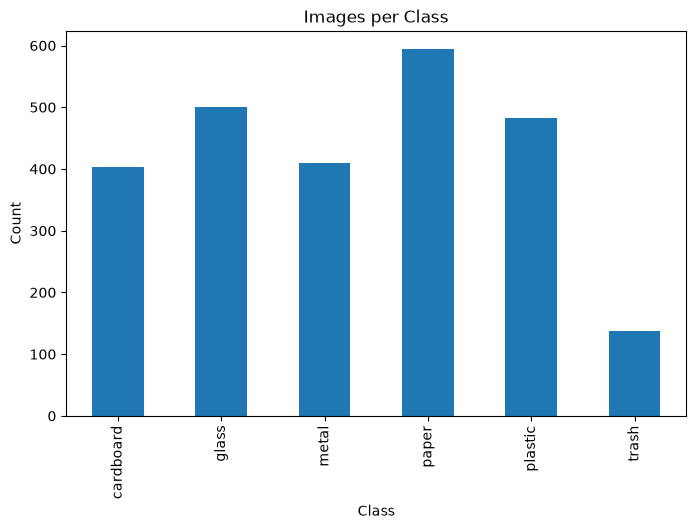

In [11]:
df.plot(
    x="Class",
    y="Number of Images",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Images per Class")
plt.ylabel("Count")
plt.show()

Display 10 Random Images per Class

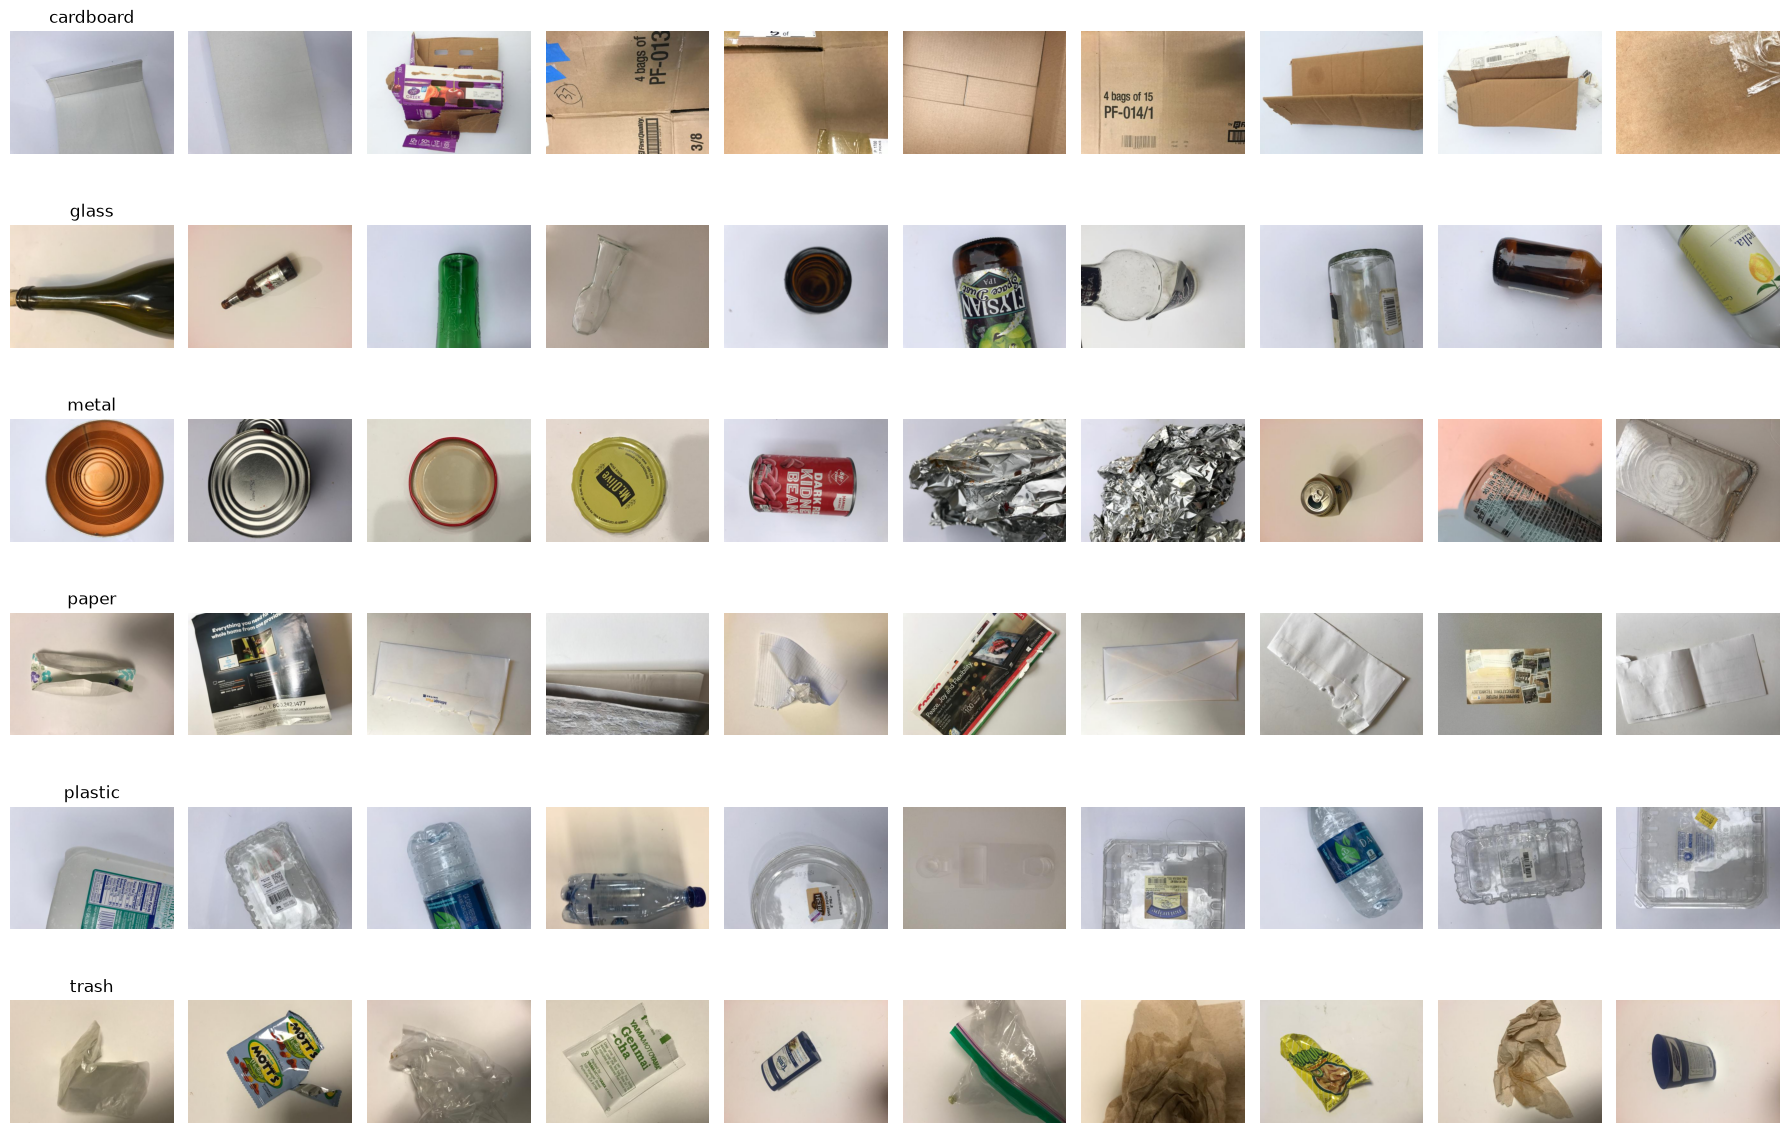

In [12]:
fig, axes = plt.subplots(len(classes), 10, figsize=(18,12))

for i, cls in enumerate(classes):

    folder = os.path.join(data_dir, cls)

    images = random.sample(os.listdir(folder), 10)

    for j, img_name in enumerate(images):

        img_path = os.path.join(folder, img_name)

        img = Image.open(img_path)

        axes[i,j].imshow(img)
        axes[i,j].axis("off")

        if j == 0:
            axes[i,j].set_title(cls)

plt.tight_layout()
plt.show()

Check Image Sizes

In [13]:
widths = []
heights = []

for cls in classes:

    folder = os.path.join(data_dir, cls)

    for file in os.listdir(folder):

        path = os.path.join(folder, file)

        img = Image.open(path)

        w, h = img.size

        widths.append(w)
        heights.append(h)

print("Minimum width:", min(widths))
print("Maximum width:", max(widths))

print("Minimum height:", min(heights))
print("Maximum height:", max(heights))

Minimum width: 512
Maximum width: 512
Minimum height: 384
Maximum height: 384


Check File Sizes

In [14]:
sizes = []

for cls in classes:

    folder = os.path.join(data_dir, cls)

    for file in os.listdir(folder):

        path = os.path.join(folder, file)

        sizes.append(os.path.getsize(path)/1024)

print("Smallest file:", min(sizes), "KB")
print("Largest file:", max(sizes), "KB")

Smallest file: 5.47265625 KB
Largest file: 56.51171875 KB


Find Corrupt Images

In [15]:
bad_images = []

for cls in classes:

    folder = os.path.join(data_dir, cls)

    for file in os.listdir(folder):

        path = os.path.join(folder, file)

        try:
            Image.open(path).verify()

        except Exception:
            bad_images.append(path)

print("Corrupt Images:", len(bad_images))
print(bad_images)

Corrupt Images: 0
[]


Create Train/Validation/Test Split

In [16]:
filepaths = []
labels = []

for cls in classes:

    folder = os.path.join(data_dir, cls)

    for file in os.listdir(folder):

        filepaths.append(os.path.join(folder,file))
        labels.append(cls)

Split into 70% train and 30% temporary:

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    filepaths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

Split the remaining 30% equally into validation and test:


In [18]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

Save the Splits

In [19]:
pd.DataFrame({
    "filepath":X_train,
    "label":y_train
}).to_csv("train.csv", index=False)

Validation CSV

In [20]:
pd.DataFrame({
    "filepath":X_val,
    "label":y_val
}).to_csv("val.csv", index=False)

Test CSV

In [21]:
pd.DataFrame({
    "filepath":X_test,
    "label":y_test
}).to_csv("test.csv", index=False)

## Observations

1. The **trash** class contains the fewest images, making the dataset imbalanced.

2. The **plastic** class appears to be the most visually diverse because plastic objects vary greatly in shape, color, and size.

3. The **glass** and **plastic** classes look very similar in some images due to reflections and transparent materials.

4. Images have different lighting conditions and backgrounds, making the dataset more realistic than CIFAR-10.

5. No corrupt images were found during verification, and most images have consistent dimensions.